In [1]:
# This stuff only actually gets used in this cell:

from matplotlib import pyplot as plt

# Use the style file defined in the repository route
plt.style.use('../../paper.mplstyle')

# This is the folder where results plots will be saved:
paper_plots_dir = '../../paper/images/zerolatency_results'

# The common and plotting utils modules are in the parent
# `search` directory
# Here we add the `search` directory to the python path so we can
# do a local import

import sys
import os

parent_dir = os.path.abspath("..")

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Everything plotted in this notebook is done using these helper modules
import common_utils
import copy
import numpy as np

# Get the truth times
import ldc.io.hdf5 as hdfio

/home/gareth.cabourndavies/environments/env_lisa_premerger_sangria/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:

# Set up some values to control things

data_file = '../../datasets/LDC2_sangria_hm_training.hdf'
delta_t = 5
sample_rate = 1 / delta_t

In [3]:
mbhb_sky, _ = hdfio.load_array(data_file, name="sky/mbhb/cat")

truth_times_s = mbhb_sky['CoalescenceTime']

In [4]:
mbhb_data = common_utils.load_ldc_timeseries(
    data_file,
    data_group='sky/mbhb/tdi',
    delta_t=delta_t,
)

In [5]:
data = common_utils.load_ldc_timeseries(
    data_file,
    delta_t=delta_t
)
del data['LISA_T']
data_time_max = data['LISA_A']._epoch + len(data['LISA_A']) / data['LISA_A'].sample_rate

In [6]:
generated = copy.deepcopy(data)
for ts in generated.values():
    ts._data = np.zeros(len(ts), dtype=np.float64)

for signal_number, mbhb in enumerate(mbhb_sky):
    # print(f'Calculating Signal {signal_number}')
    wf = common_utils.generate_waveform_for_data(
        mbhb,
        0,
        365 * 86400,
        delta_t,
    )
    # print('Adding to timeseries')
    for channel in generated.keys():
        generated[channel] += wf[channel]

# print('Subtracting from data')
data_residual = {
    channel: data[channel] - generated[channel]
    for channel in data.keys()
}
# print('subtracting from MBHB-only dataset')
mbhb_residual = {
    channel: mbhb_data[channel] - generated[channel]
    for channel in data.keys()
}

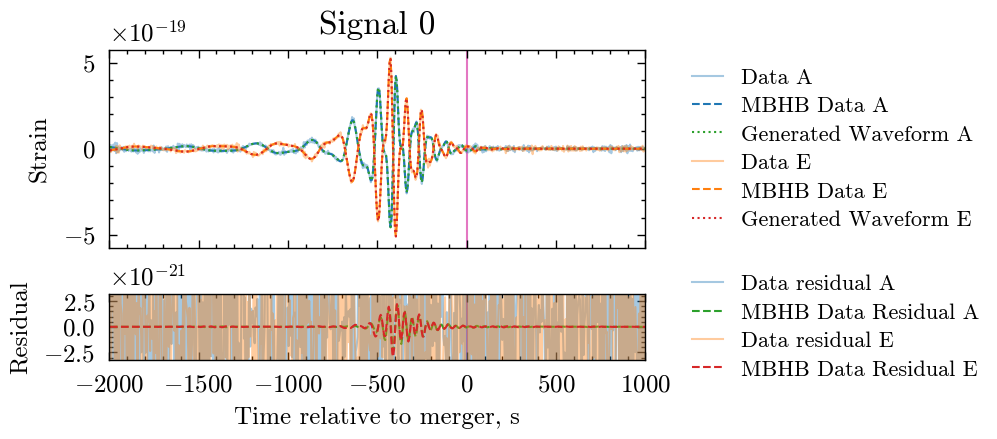

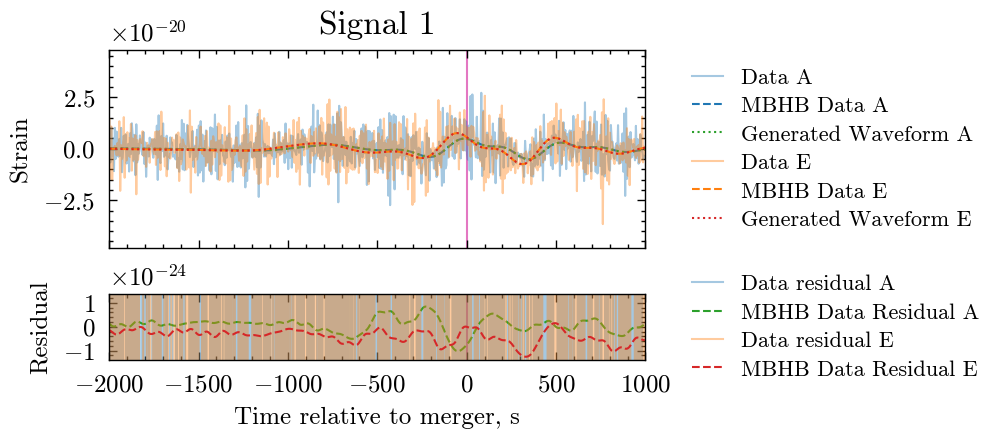

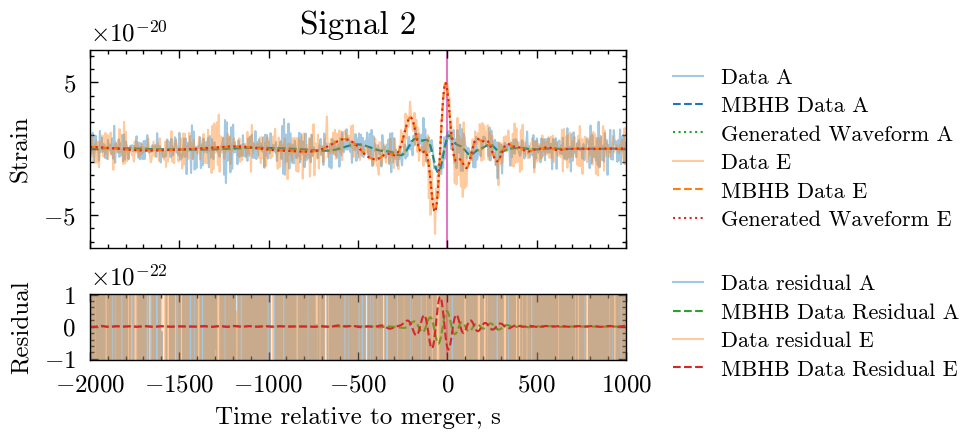

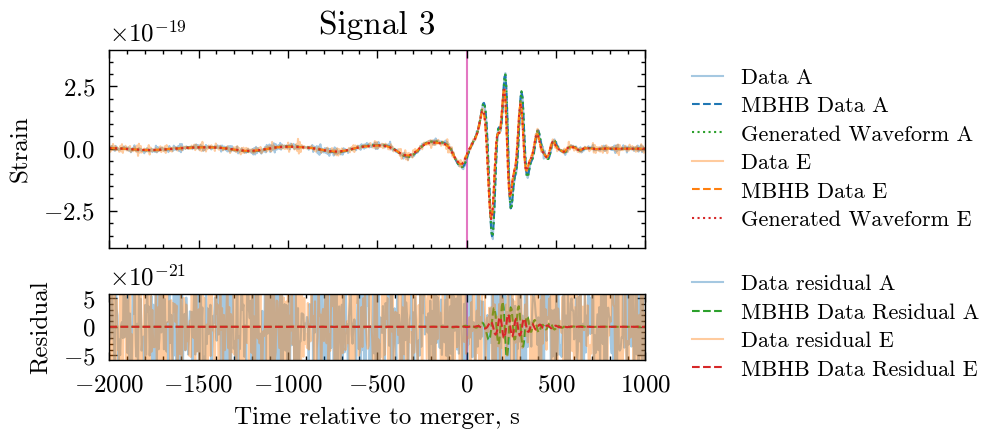

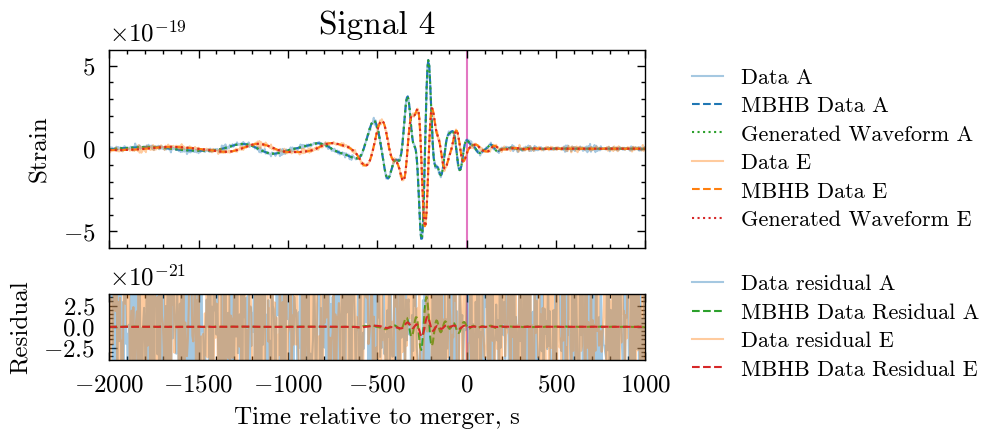

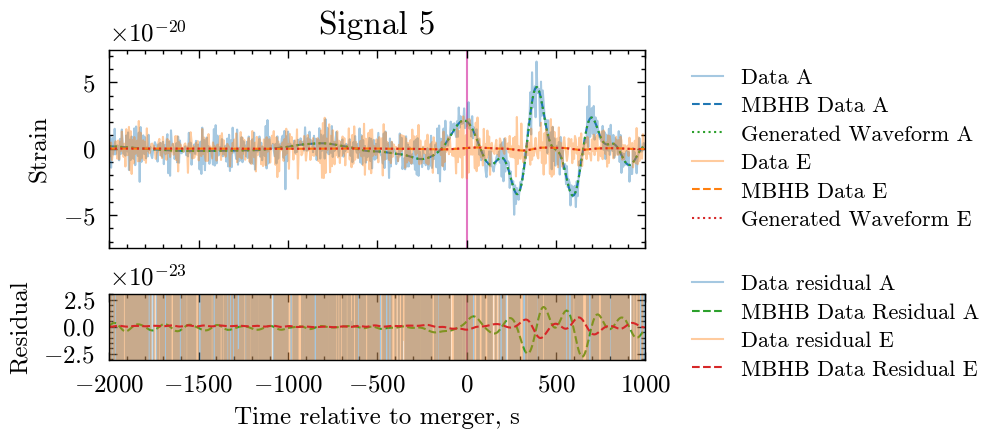

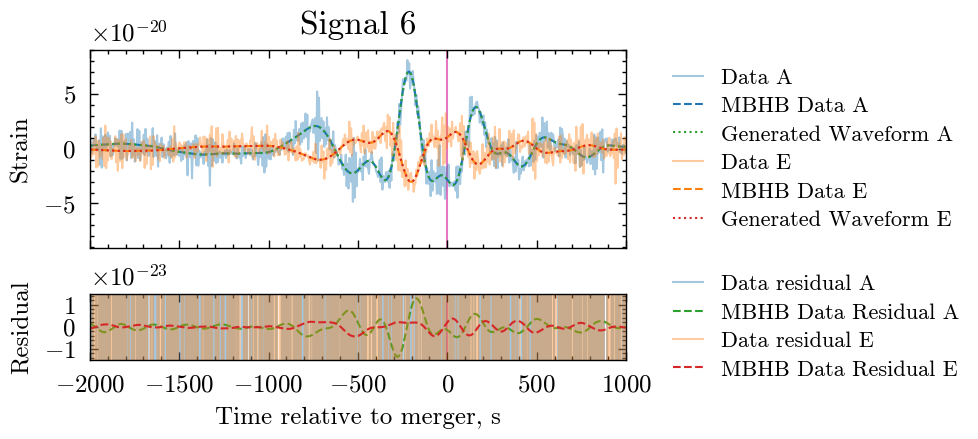

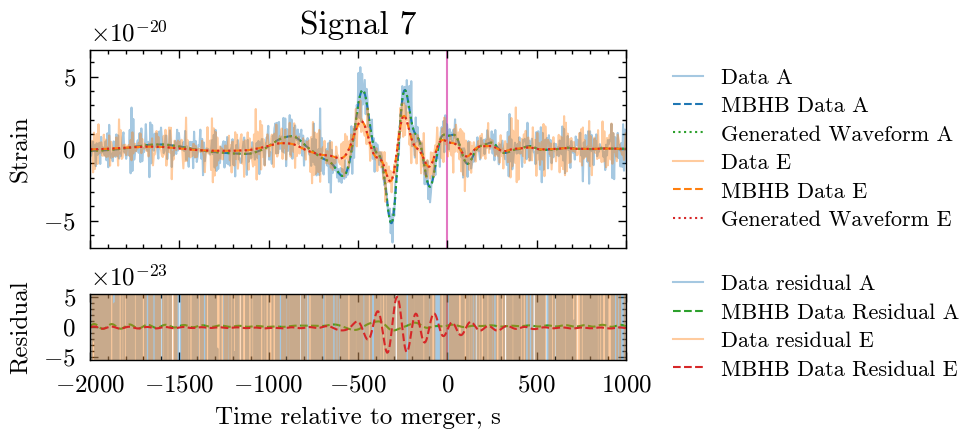

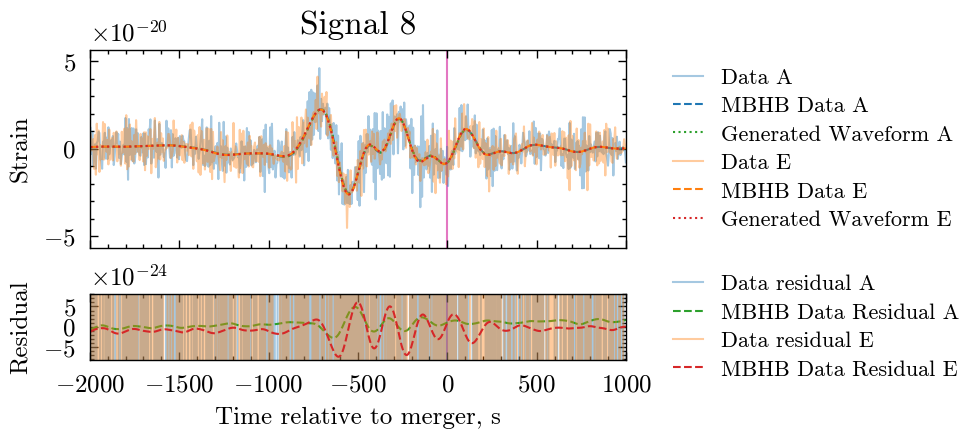

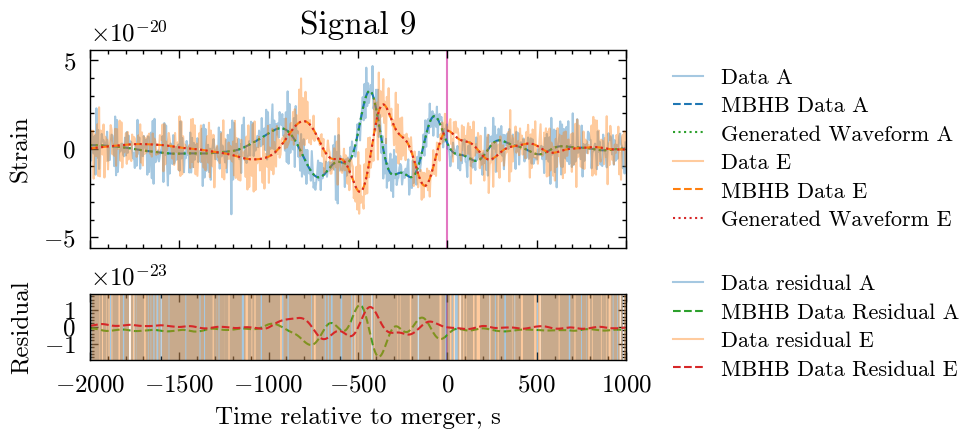

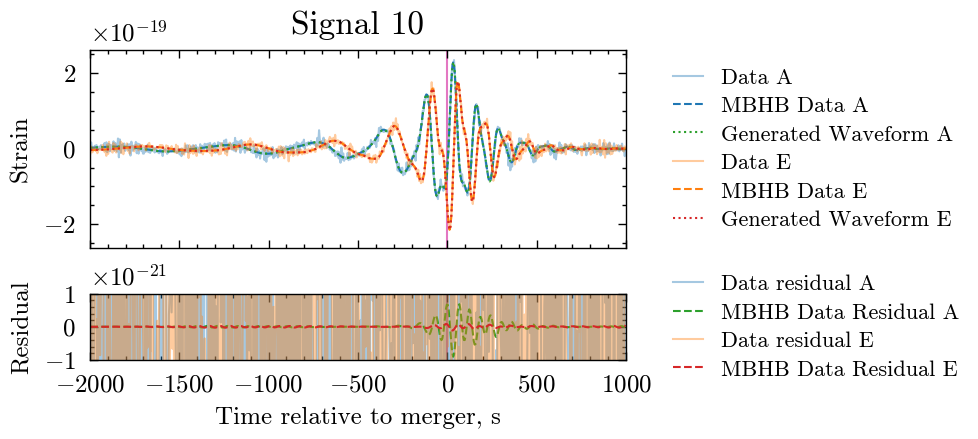

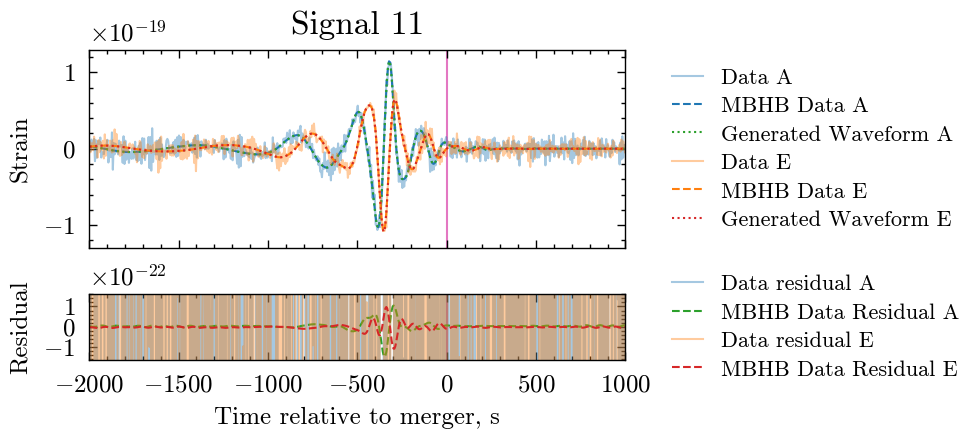

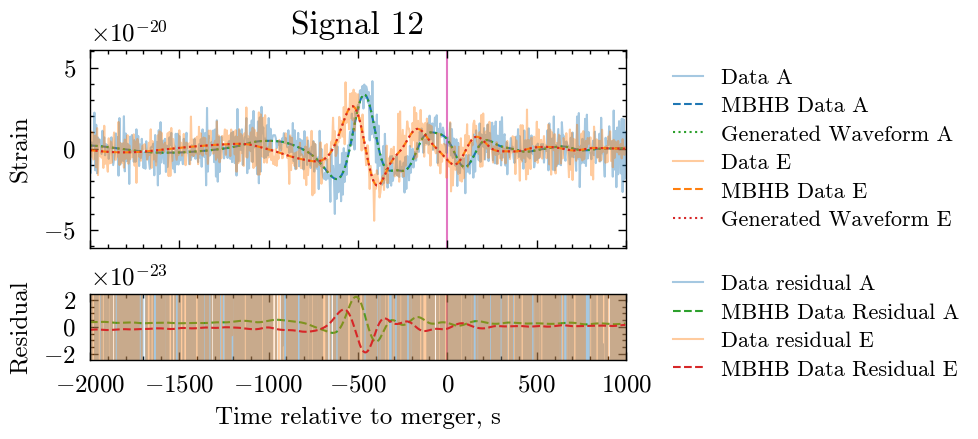

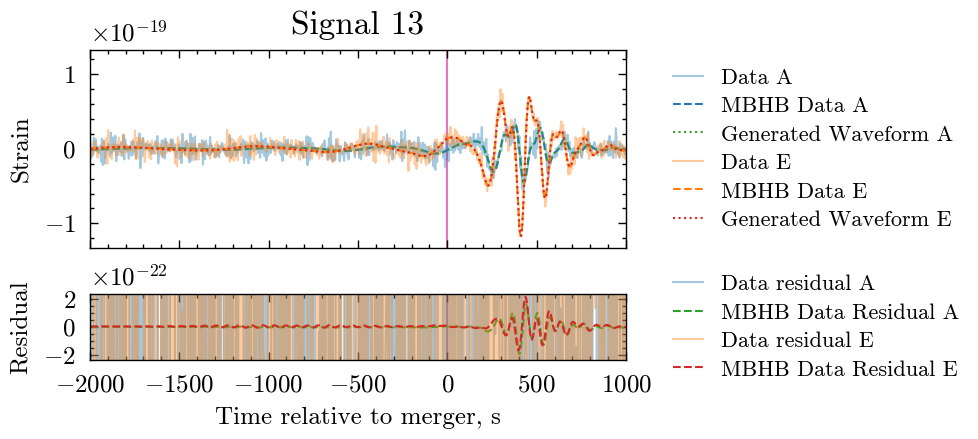

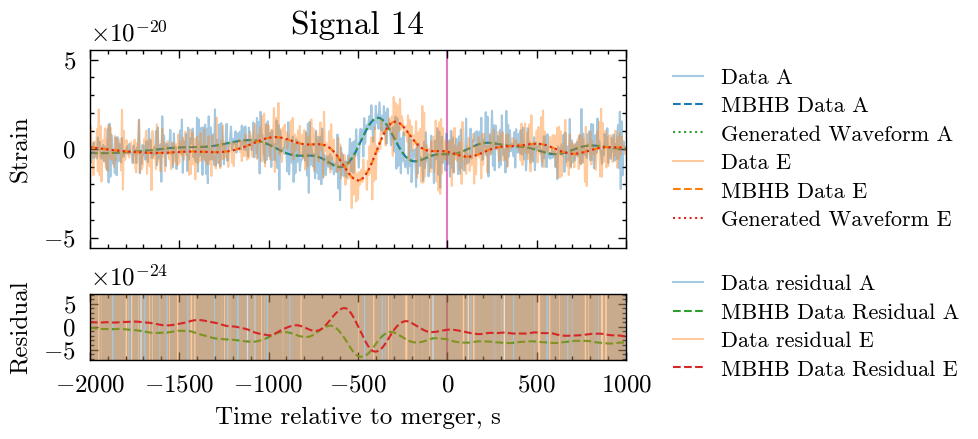

In [8]:
for signal_number, mbhb in enumerate(mbhb_sky):
    coalescence_time = mbhb['CoalescenceTime']
    max_residual = 0
    max_data = 0

    plot_bounds = (-2000, 1000)
    times = data['LISA_A'].sample_times - coalescence_time
    within_plot = np.logical_and(
        times >= plot_bounds[0],
        times <= plot_bounds[1]
    )
    # Cut the data to only the time around the coalescence
    fig, (ax1, ax2) = plt.subplots(
        2,
        sharex='col',
        height_ratios=[3,1],
    )
    fig.subplots_adjust(hspace=0.35)
    channel_colours = {
        'LISA_A': 'tab:blue',
        'LISA_E': 'tab:orange',
    }
    generated_colours = {
        'LISA_A': 'tab:green',
        'LISA_E': 'tab:red',
    }
    for channel in data.keys():
        channel_str = channel.split('_')[-1]
        max_data = max(max_data, max(abs(data[channel][within_plot])))
        max_residual = max(max_residual, max(abs(mbhb_residual[channel][within_plot])))
        mean_data = np.mean(data[channel][within_plot])
        ax1.plot(
            times[within_plot],
            data[channel][within_plot] - mean_data,
            label=f'Data {channel_str}',
            linestyle='-',
            c=channel_colours[channel],
            alpha=0.4
        )
        ax1.plot(
            times[within_plot],
            mbhb_data[channel][within_plot],
            label=f'MBHB Data {channel_str}',
            linestyle='--',
            c=channel_colours[channel]
        )
        ax1.plot(
            times[within_plot],
            generated[channel][within_plot],
            label=f'Generated Waveform {channel_str}',
            linestyle=':',
            c=generated_colours[channel]
        )
        ax2.plot(
            times[within_plot],
            data_residual[channel][within_plot] - mean_data,
            label=f'Data residual {channel_str}',
            linestyle='-',
            c=channel_colours[channel],
            alpha=0.4
        )
        ax2.plot(
            times[within_plot],
            mbhb_residual[channel][within_plot],
            label=f'MBHB Data Residual {channel_str}',
            linestyle='--',
            c=generated_colours[channel]
        )
    for truth_time_s in truth_times_s:
        ax1.axvline((truth_time_s - coalescence_time), zorder=-100, c='tab:pink')
        ax2.axvline((truth_time_s - coalescence_time), zorder=-100, c='tab:pink')
    ax2.set_xlim(-2000, 1000)
    ax1.set_ylim(-1.1 * max_data, 1.1 * max_data)
    ax2.set_ylim(-1.1 * max_residual, 1.1 * max_residual)
    ax1.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    ax2.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
    ax1.set_ylabel('Strain')
    ax2.set_ylabel('Residual')
    ax2.set_xlabel('Time relative to merger, s')

    ax1.set_title(f'Signal {signal_number}')
    fig.show()
